In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("notebook-test").getOrCreate()
spark.range(5).show()
spark.stop()

+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



In [3]:
print(spark.sparkContext._jvm.java.lang.System.getProperty("java.version"))
print(spark.sparkContext._jvm.java.lang.System.getProperty("java.vendor"))

17.0.17
Eclipse Adoptium


In [4]:
# Create SparkSession (entry point for Spark)
spark = (
    SparkSession.builder
    .master("local[*]")              # Use all available CPU cores
    .appName("KMeans_Performance_mini-project")  # Name of the Spark application
    .config("spark.driver.memory", "4g")  # Allocate memory for Spark driver
    .getOrCreate()                   # Create or reuse SparkSession
)

In [5]:
from pathlib import Path
import pandas as pd

def find_repo_root(start: Path | None = None) -> Path:
    """
    Repo root is defined as the directory that contains `data/dataset.txt`
    """
    start = (start or Path.cwd()).resolve()

    for p in [start, *start.parents]:
        if (p / "data" / "dataset.txt").exists():
            return p

    raise FileNotFoundError(
        "Cannot find repo root. Expected `data/dataset.txt` in a parent directory.\n"
        "Have you run the data preparation script?"
    )

# 1) find repo root robustly
repo_root = find_repo_root()

# 2) read dataset pointer
pointer_file = repo_root / "data" / "dataset.txt"
dataset_dir = Path(pointer_file.read_text(encoding="utf-8").strip())


In [6]:
# 3) load data
csv_path = str(next(dataset_dir.glob("*.csv")))   # Spark ต้องการ string path

sdf = (spark.read
       .option("header", True)
       .option("inferSchema", True)
       .csv(csv_path))

sdf.show(5, truncate=False)
sdf.printSchema()

+---+-------+--------+-------------------+-------------------+-----------------+------------------+-------+-------+------------+-------------------------------------------------------------------------------------+-------------------------+------------+----------+-----+----------+-------+----------+------------+-------------------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
|ID |Source |Severity|Start_Time         |End_Time           |Start_Lat        |Start_Lng         |End_Lat|End_Lng|Distance(mi)|Description                                                                          |Street                   |City        |County    |State|Zipcode   |Country|Timezone  |Airport_Code|Weather_Timestamp  |T

In [18]:
sdf.head(), sdf.dtypes

(Row(ID='A-1', Source='Source2', Severity=3, Start_Time=datetime.datetime(2016, 2, 8, 5, 46), End_Time=datetime.datetime(2016, 2, 8, 11, 0), Start_Lat=39.865147, Start_Lng=-84.058723, End_Lat=None, End_Lng=None, Distance(mi)=0.01, Description='Right lane blocked due to accident on I-70 Eastbound at Exit 41 OH-235 State Route 4.', Street='I-70 E', City='Dayton', County='Montgomery', State='OH', Zipcode='45424', Country='US', Timezone='US/Eastern', Airport_Code='KFFO', Weather_Timestamp=datetime.datetime(2016, 2, 8, 5, 58), Temperature(F)=36.9, Wind_Chill(F)=None, Humidity(%)=91.0, Pressure(in)=29.68, Visibility(mi)=10.0, Wind_Direction='Calm', Wind_Speed(mph)=None, Precipitation(in)=0.02, Weather_Condition='Light Rain', Amenity=False, Bump=False, Crossing=False, Give_Way=False, Junction=False, No_Exit=False, Railway=False, Roundabout=False, Station=False, Stop=False, Traffic_Calming=False, Traffic_Signal=False, Turning_Loop=False, Sunrise_Sunset='Night', Civil_Twilight='Night', Nautical

In [24]:
from pyspark.sql.types import StructField
print(sdf.schema.fields)

[StructField('ID', StringType(), True), StructField('Source', StringType(), True), StructField('Severity', IntegerType(), True), StructField('Start_Time', TimestampType(), True), StructField('End_Time', TimestampType(), True), StructField('Start_Lat', DoubleType(), True), StructField('Start_Lng', DoubleType(), True), StructField('End_Lat', DoubleType(), True), StructField('End_Lng', DoubleType(), True), StructField('Distance(mi)', DoubleType(), True), StructField('Description', StringType(), True), StructField('Street', StringType(), True), StructField('City', StringType(), True), StructField('County', StringType(), True), StructField('State', StringType(), True), StructField('Zipcode', StringType(), True), StructField('Country', StringType(), True), StructField('Timezone', StringType(), True), StructField('Airport_Code', StringType(), True), StructField('Weather_Timestamp', TimestampType(), True), StructField('Temperature(F)', DoubleType(), True), StructField('Wind_Chill(F)', DoubleTy

In [12]:
# PySpark DataFrame doesn't have `.shape`. Use `.count()` for rows (expensive) and len(columns) for cols.
rows = sdf.count()  # this runs a Spark job on the dataset
cols = len(sdf.columns)
print(f"shape: ({rows}, {cols})")

shape: (7728394, 46)


### Find missing values

In [28]:
from pyspark.sql.functions import col, sum

missing_df = sdf.select([sum(col(c).isNull().cast("int")).alias(c) for c in sdf.columns])
missing_df.show()

+---+------+--------+----------+--------+---------+---------+-------+-------+------------+-----------+------+----+------+-----+-------+-------+--------+------------+-----------------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+----+--------+--------+--------+-------+-------+----------+-------+----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
| ID|Source|Severity|Start_Time|End_Time|Start_Lat|Start_Lng|End_Lat|End_Lng|Distance(mi)|Description|Street|City|County|State|Zipcode|Country|Timezone|Airport_Code|Weather_Timestamp|Temperature(F)|Wind_Chill(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|Weather_Condition|Amenity|Bump|Crossing|Give_Way|Junction|No_Exit|Railway|Roundabout|Station|Stop|Traffic_Calming|Traffic_Signal|Turning_Loop|Sunrise_Sunset|Civil_Twilight|Nautical_Twil

In [ ]:
rows = sdf.count()
missing_counts = sdf.select([sum(col(c).isNull().cast("int")).alias(c) for c in sdf.columns]).collect()[0].asDict()

import pandas as pd  # pandas was imported earlier; this won't re-import if already present
miss_df = pd.Series(missing_counts, name="missing_count").to_frame()
miss_df["missing_pct"] = (miss_df["missing_count"] / rows) * 100
miss_df = miss_df.sort_values("missing_count", ascending=False)

print(f"rows: {rows}, cols: {len(sdf.columns)}")
miss_df

### Separate Categorical and Numerical

In [7]:
from pyspark.sql.types import StructField

categorical_cols = [field.name for field in sdf.schema.fields if field.dataType.typeName() == 'string' or field.dataType.typeName() == 'boolean']
numerical_cols = [field.name for field in sdf.schema.fields if field.dataType.typeName() in ['integer','int', 'double', 'bigint']]
datetype_cols = {field.name for field in sdf.schema.fields if field.dataType.typeName() in ['date','Timezone','Weather_Timestamp', 'timestamp']}

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\nDate/Time columns ({len(datetype_cols)}): {datetype_cols}")

Categorical columns (30): ['ID', 'Source', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Wind_Direction', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']

Numerical columns (13): ['Severity', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

Date/Time columns (3): {'End_Time', 'Start_Time', 'Weather_Timestamp'}


### Find Skewness

In [8]:
from pyspark.sql.functions import skewness
sdf.select([skewness(c) for c in numerical_cols]).show()

+------------------+--------------------+-------------------+--------------------+-------------------+----------------------+------------------------+-----------------------+---------------------+----------------------+------------------------+-------------------------+---------------------------+
|skewness(Severity)| skewness(Start_Lat)|skewness(Start_Lng)|   skewness(End_Lat)|  skewness(End_Lng)|skewness(Distance(mi))|skewness(Temperature(F))|skewness(Wind_Chill(F))|skewness(Humidity(%))|skewness(Pressure(in))|skewness(Visibility(mi))|skewness(Wind_Speed(mph))|skewness(Precipitation(in))|
+------------------+--------------------+-------------------+--------------------+-------------------+----------------------+------------------------+-----------------------+---------------------+----------------------+------------------------+-------------------------+---------------------------+
| 1.814723662711441|-0.07222071123542279|-0.4829195314374511|-0.15821717508531996|-0.3654920977637065| 

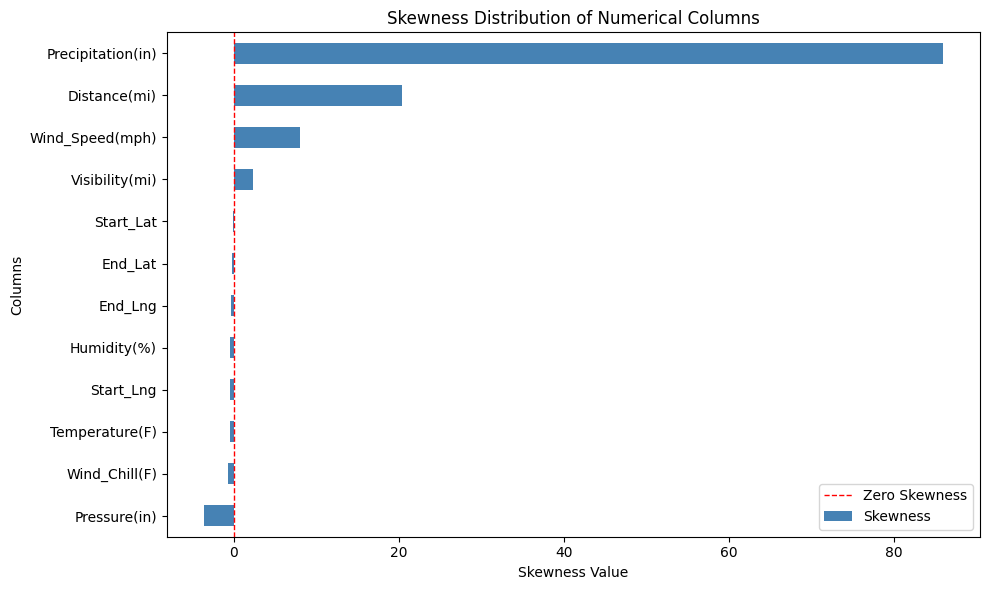

In [21]:
from pyspark.sql.functions import skewness
import pandas as pd

import matplotlib.pyplot as plt

# Calculate skewness for all numerical columns
skewness_data = sdf.select([skewness(c).alias(c) for c in numerical_cols]).collect()[0]

# Convert to pandas for plotting
skewness_df = pd.DataFrame([skewness_data.asDict()]).T
skewness_df.columns = ['Skewness']
skewness_df = skewness_df.sort_values('Skewness')

# Plot
plt.figure(figsize=(10, 6))
skewness_df['Skewness'].plot(kind='barh', color='steelblue')
plt.xlabel('Skewness Value')
plt.ylabel('Columns')
plt.title('Skewness Distribution of Numerical Columns')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Zero Skewness')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
from pyspark.sql.functions import skewness

sdf.select(skewness("Severity")).show()


+------------------+
|skewness(Severity)|
+------------------+
| 1.814723662711441|
+------------------+



### Drop uneed columns


In [ ]:
sdf = sdf.drop('End_Lat',           # many missing values
               'End_Lng',           # many missing values
               'Wind_Chill(F)',     # many missing values
               'Description',       # unuseful free-text column
               'Zipcode',           # many missing values  
               'Airport_Code',      # many missing values
               'Weather_Timestamp') # many missing values

## TARGET VARIABLE ANALYSIS (SEVERITY)


In [ ]:
from pyspark.sql.functions import col

rows = sdf.count()

severity_dist = (sdf.groupBy("Severity")
                 .count())
severity_dist = severity_dist.withColumn("percentage", (col("count") / rows) * 100)
severity_dist = severity_dist.sort("Severity")
severity_dist.show()

##  Class Imbalance Analysis:
• Most frequent class: 79.67%\
• Least frequent class: 0.87%\
• Imbalance ratio: 91.40:1\
 Dataset is imbalanced - consider sampling strategies

In [ ]:
state_dist = (sdf.groupBy("State")
                 .count())

state_dist = state_dist.withColumn("percentage", (col("count") / rows) * 100)
state_dist = state_dist.sort("State")
state_dist.show()